# Analysis of cross‑Section sampling using SANDY

In [1]:
import sandy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


In this section, we perform a complete uncertainty analysis of U‑234 nuclear data using a set of **20 random ENDF‑6 files** generated with SANDY.

For each random ENDF file:

- we load the correspnding PENDF (pointwise ENDF) for cross sections
- we extract cross‑section samples for multiple MT reactions
- we compute sample means and sample standard deviations
- we compare the sample statistics with the expected uncertainty from the official ENDF-6 covariance (ERRORR)
- we compute bootstrap confidence intervals for the sample standard deviation
- we visualize uncertainty behavior across energy regions

> This provides both visual and statistical validation that the stochastic sampling matches the nuclear data covariance information.

## Loading Random ENDF6 and PENDF Files

We begin by loading:

- 20 random ENDF‑6 files containing stochastic variations nubar
- 20 corresponding PENDF files, where NJOY has already produced pointwise cross sections

The random files were produced running `sandy` from the command line interface with:

```bash
python -m sandy.samping U234.dat --samples 20 --processes 1 --acer --temperature 293.15
```

The `sandy` API is used for parsing and data extraction.

In [2]:
sample_size = 20

In [3]:
endf6_tapes = {i: sandy.Endf6.from_file(f"92234_{i}.endf6") for i in range(sample_size)}

In [4]:
pendf_tapes = {i: sandy.Endf6.from_file(f"92234_{i}.pendf") for i in range(sample_size)}

We then collect the MT‑specific cross‑section samples into pandasd DataFrames:

 - MT=2 → elastic scattering
 - MT=4 → inelastic scattering
 - MT=18 → fission
 - MT=102 → radiative capture

In [5]:
xss = {k: sandy.Xs.from_endf6(v, read_nubar=False) for k, v in pendf_tapes.items()}
xss_ = {}
for mt in [2, 4, 18, 102]:
    xss_[mt] = pd.DataFrame({k: v.data[9225, mt] for k, v in xss.items()})

Similarly, we extract nubar components:

 - MT=452 → total
 - MT=455 → delayed
 - MT=456 → prompt

In [6]:
nus = {k: sandy.Xs.from_endf6(v, read_xs=False) for k, v in endf6_tapes.items()}
nus_ = {}
for mt in [452, 455, 456]:
    nus_[mt] = pd.DataFrame({k: v.data[9225, mt] for k, v in nus.items()})

## Plotting the Sampled Cross Sections

We can draw all 20 sampled cross sections for a selected reaction MT.

We can choose different energy windows, for example:

 - Full range
 - First resonance
 - Beyond RRR

This allows us to visually inspect how sampling affects different energy regions of the cross section.

Key features:

 - Each thin line is one sample
 - The ensemble shows how strongly the cross section varies due to nuclear data uncertainty

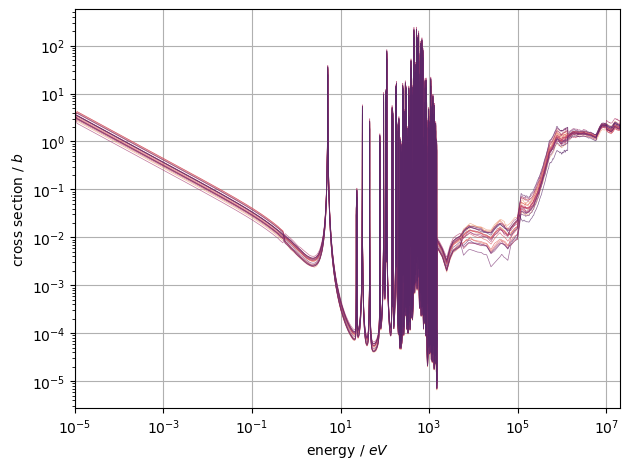

In [7]:
mt = 18

# FULL RANGE
xlim = 1e-5, 2e7
ylim = None, None
logx=True
logy=True

# # FIRST RES, FISSION
# xlim = 4, 6
# ylim = 1e-3, None
# logx=False
# logy=True

# # BEYOND RRR, FISSION
# xlim = 2e3, 1e5
# ylim = 1e-3, 1e-1
# logx=True
# logy=True

fig, ax = plt.subplots()

colors = sns.color_palette("flare", n_colors=len(xss_[mt].columns))

xss_[mt].plot(logx=logx, logy=logy, alpha=.7, lw=.5, ax=ax, color=colors)
ax.legend().remove()

ax.set(xlabel="energy / $eV$", ylabel="cross section / $b$", xlim=xlim, ylim=ylim)
ax.grid()

fig.tight_layout()

Let's also plot nubar.

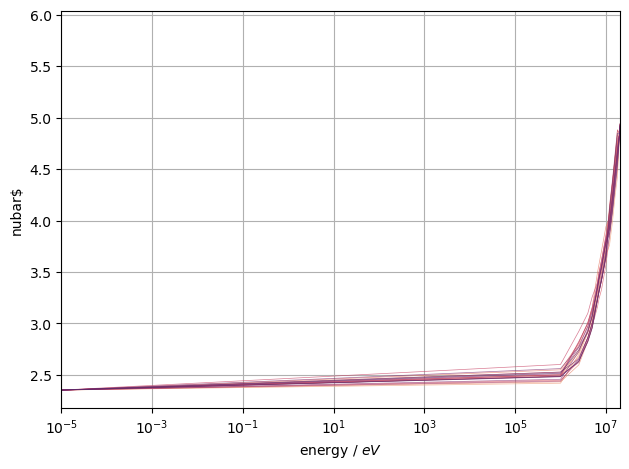

In [8]:
mt = 456

# FULL RANGE
xlim = 1e-5, 2e7
ylim = None, None
logx=True
logy=False

fig, ax = plt.subplots()

colors = sns.color_palette("flare", n_colors=len(nus_[mt].columns))

nus_[mt].plot(logx=logx, logy=logy, alpha=.7, lw=.5, ax=ax, color=colors)
ax.legend().remove()

ax.set(xlabel="energy / $eV$", ylabel="nubar$", xlim=xlim, ylim=ylim)
ax.grid()

fig.tight_layout()

## Mean and Standard Deviation of Cross‑Section Samples

For a selected MT, we compute:

- sample mean at each energy
- sample standard deviation at each energy

These give empirical estimates of cross‑section uncertainty.

The plot shows:

- red curve = sample mean
- black dashed curves = ±1 sample standard deviation

This provides a visual estimate of the uncertainty band associated with the sampling.

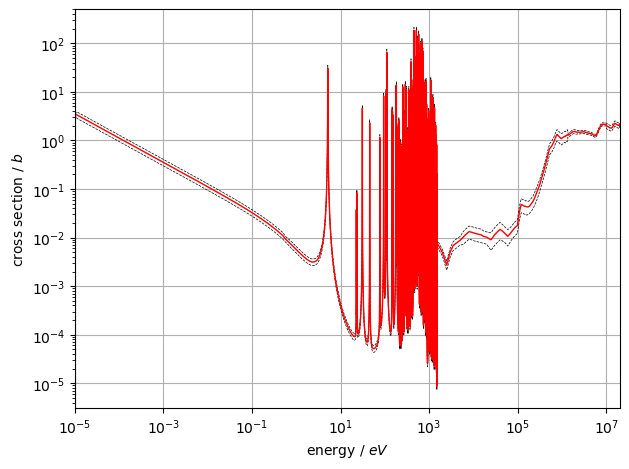

In [9]:
mt = 18

mean = xss_[mt].mean(axis=1)
std = xss_[mt].std(axis=1)

# REF
xlim = 1e-5, 2e7
ylim = None, None
logx=True
logy=True

# # FIRST RES, FISSION
# xlim = 4, 6
# ylim = 1e-3, None
# logx=False
# logy=True

# # BEYOND RRR, FISSION
# xlim = 2e3, 1e5
# ylim = 1e-3, 1e-1
# logx=True
# logy=True

fig, ax = plt.subplots()
(mean + std).plot(alpha=1, lw=.5, ls='--', color="k", ax=ax)
(mean - std).plot(alpha=1, lw=.5, ls='--', color="k", ax=ax)
mean.plot(logx=logx, logy=logy, alpha=1, lw=1, color="r", ax=ax)

ax.grid()
ax.set(xlabel="energy / $eV$", ylabel="cross section / $b$", xlim=xlim, ylim=ylim)

fig.tight_layout()

## Comparison with ENDF Covariance (ERRORR)

We load the ERRORR covariance block from the reference U-234 ENDF-6 file `U234.dat` and extract the covariance matrix for cross sections.

In [10]:
tape = sandy.Endf6.from_file("U234.dat")
err = tape.get_errorr()

cov31 = err["errorr31"].get_cov()
cov33 = err["errorr33"].get_cov()

We compute the relative standard deviation of the samples:

$rstd(E) = \frac{std(E)}{mean(E)}$

and plot:

- red step curve = expected STD from ENDF covariance
- black markers = sample STD from SANDY sampling

This comparison validates that the random ENDF generation reproduces ENDF covariance correctly.

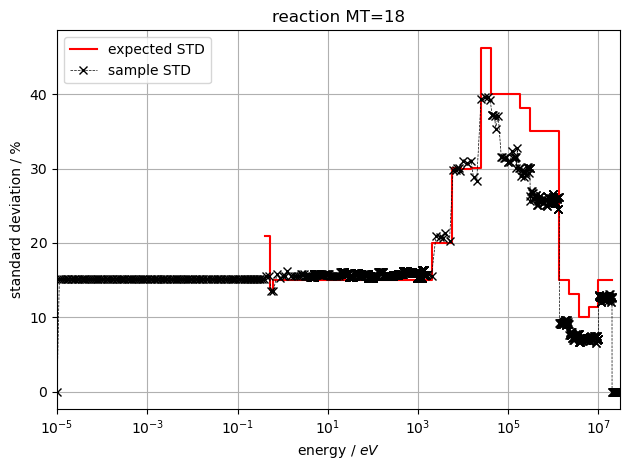

In [11]:
mt = 18
mean = xss_[mt].mean(axis=1)
std = xss_[mt].std(axis=1)

fig, ax = plt.subplots()

std33 = cov33.get_std().multiply(100).reset_index().query("MT==@mt")
std33["ERIGHT"] = [x.right for x in std33.E]
std33["ELEFT"] = [x.left for x in std33.E]
std33.plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, label="expected STD", color="red")

rstd = std / mean * 100
rstd.plot(logx=True, marker="x", ax=ax, label="sample STD", ls="--", lw=.5, color="k")

ax.legend()
ax.grid()
ax.set(
    xlim=(1e-5, 3e7),
    xlabel="energy / $eV$",
    ylabel="standard deviation / %",
    title=f"reaction MT={mt}",
)

fig.tight_layout()

## Bootstrap Confidence Intervals for Sample STD

To quantify sampling uncertainty, we compute bootstrap confidence intervals for the standard deviation at each energy point.

In [12]:
def get_confidence_intervals(df, n_resamples=100, confidence_level=0.95):
    import numpy as np
    from scipy.stats import bootstrap
    
    # xss_[mt] shape: (16795, 50)
    data = (df.T,)  # transpose so shape is (50, 16795)
                           # bootstrap expects samples along axis=0
    
    # Define a statistic function that works on 2D input
    # It should return an array of stds along axis=0 (over samples)
    def row_std(arr, axis=0):
        return np.std(arr, axis=axis)
    
    # Call bootstrap
    res = bootstrap(
        data,
        statistic=row_std,
        confidence_level=confidence_level,
        n_resamples=n_resamples,
        method='percentile',
        vectorized=True
    )
    
    # Extract confidence intervals
    ci_lower, ci_upper = res.confidence_interval.low, res.confidence_interval.high
    return ci_lower, ci_upper

The final figure includes:

- Expected STD from ENDF covariance (red, ERRORR)
- Sample STD from SANDY sampling (black × markers)
- Bootstrap 95% confidence band (shaded gray)

Interpretation:

- Overlap of sample STD with the expected STD confirms the sampling reproduces the true covariance.
- The width of the bootstrap band shows uncertainty due to limited sample size (here 20 samples).
- Deviations indicate regions where:
    - sampling variance is not converged yet, or
    - non‑Gaussian effects exist

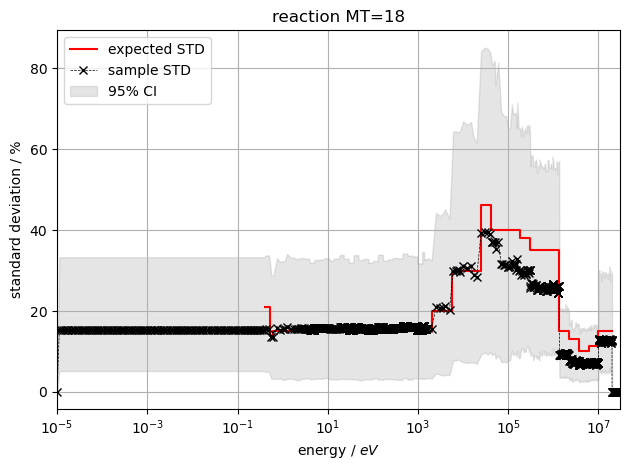

In [13]:
mt = 18
mean = xss_[mt].mean(axis=1)
std = xss_[mt].std(axis=1)

fig, ax = plt.subplots()

std33 = cov33.get_std().multiply(100).reset_index().query("MT==@mt")
std33["ERIGHT"] = [x.right for x in std33.E]
std33["ELEFT"] = [x.left for x in std33.E]
std33.plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, label="expected STD", color="red")

rstd = std / mean * 100
rstd.plot(logx=True, marker="x", ax=ax, label="sample STD", ls="--", lw=.5, color="k")

confidence_level = 0.95
ci_lower, ci_upper = get_confidence_intervals(xss_[mt], confidence_level=confidence_level)
# Compute the upper and lower bounds for shading
lower = (std - ci_lower) / mean * 100
upper = (std + ci_upper) / mean * 100

# Fill the confidence interval
plt.fill_between(mean.index, lower, upper, color='gray', alpha=0.2, label=f'{confidence_level*100:.0f}% CI')

ax.legend()
ax.grid()
ax.set(
    xlim=(1e-5, 3e7),
    xlabel="energy / $eV$",
    ylabel="standard deviation / %",
    title=f"reaction MT={mt}",
)

fig.tight_layout()

Let's try with prompt nubar.

Where is the difference?

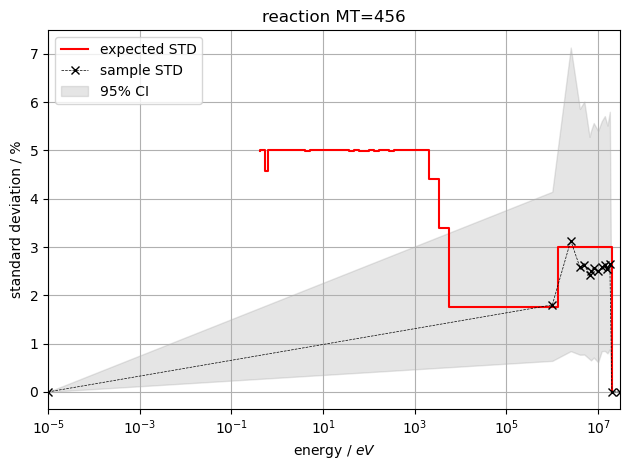

In [14]:
mt = 456
mean = nus_[mt].mean(axis=1)
std = nus_[mt].std(axis=1)

fig, ax = plt.subplots()

std31 = cov31.get_std().multiply(100).reset_index().query("MT==@mt")
std31["ERIGHT"] = [x.right for x in std31.E]
std31["ELEFT"] = [x.left for x in std31.E]
std31.plot(x="ERIGHT", y="STD", ds="steps-pre", ax=ax, label="expected STD", color="red")

rstd = std / mean * 100
rstd.plot(logx=True, marker="x", ax=ax, label="sample STD", ls="--", lw=.5, color="k")

confidence_level = 0.95
ci_lower, ci_upper = get_confidence_intervals(nus_[mt], confidence_level=confidence_level)
# Compute the upper and lower bounds for shading
lower = (std - ci_lower) / mean * 100
upper = (std + ci_upper) / mean * 100

# Fill the confidence interval
plt.fill_between(mean.index, lower, upper, color='gray', alpha=0.2, label=f'{confidence_level*100:.0f}% CI')

ax.legend()
ax.grid()
ax.set(
    xlim=(1e-5, 3e7),
    xlabel="energy / $eV$",
    ylabel="standard deviation / %",
    title=f"reaction MT={mt}",
)

fig.tight_layout()